In [1]:
import pandas as pd

In [2]:
df_crops = pd.read_csv('Corn vs Soybeans, Irrigated vs Non-Irrigated, County Level, 2000-2024.csv', on_bad_lines='skip')
df_drought = pd.read_csv('Drought data.csv', on_bad_lines='skip')

In [3]:
print("Crop data")
print(df_crops.head())
print("\nDrought Data")
print(df_drought.head())

Crop data
  Program  Year Period Geo Level     State  State ANSI Ag District  \
0  SURVEY  2024   YEAR    COUNTY  DELAWARE          10         NaN   
1  SURVEY  2024   YEAR    COUNTY  DELAWARE          10         NaN   
2  SURVEY  2024   YEAR    COUNTY  DELAWARE          10         NaN   
3  SURVEY  2024   YEAR    COUNTY  DELAWARE          10         NaN   
4  SURVEY  2024   YEAR    COUNTY  DELAWARE          10    SOUTHERN   

   Ag District Code          County County ANSI Commodity  \
0                99  OTHER COUNTIES         NaN      CORN   
1                99  OTHER COUNTIES         NaN      CORN   
2                99  OTHER COUNTIES         NaN  SOYBEANS   
3                99  OTHER COUNTIES         NaN  SOYBEANS   
4                80          SUSSEX           5      CORN   

                                           Data Item  Value  
0  CORN, GRAIN, IRRIGATED - YIELD, MEASURED IN BU...  217.9  
1  CORN, GRAIN, NON-IRRIGATED - YIELD, MEASURED I...  154.2  
2  SOYBEANS, IRR

In [4]:
df_modifiedCrops = df_crops[['Year', 'State', 'Commodity', 'Data Item', 'Value']]
# Gets the average yield in bushels/acre per state
df_modifiedCrops = df_modifiedCrops.groupby(['Year', 'State', 'Data Item'])['Value'].mean().reset_index()
# Create a pivot table to combine different data items (e.g. irrigated and non-irrigated) into the same row
df_modifiedCrops = df_modifiedCrops.pivot_table(index=['Year', 'State'], columns='Data Item', values='Value').reset_index()
df_modifiedCrops.columns.name = None
df_modifiedCrops.columns = ['Year', 'State', 'Corn_Irrigated', 'Corn_NonIrrigated', 'Soy_Irrigated', 'Soy_NonIrrigated']
# Use State abbreviations
state_abbrev = {
    'ALABAMA': 'AL', 'ALASKA': 'AK', 'ARIZONA': 'AZ', 'ARKANSAS': 'AR',
    'CALIFORNIA': 'CA', 'COLORADO': 'CO', 'CONNECTICUT': 'CT', 'DELAWARE': 'DE',
    'FLORIDA': 'FL', 'GEORGIA': 'GA', 'HAWAII': 'HI', 'IDAHO': 'ID',
    'ILLINOIS': 'IL', 'INDIANA': 'IN', 'IOWA': 'IA', 'KANSAS': 'KS',
    'KENTUCKY': 'KY', 'LOUISIANA': 'LA', 'MAINE': 'ME', 'MARYLAND': 'MD',
    'MASSACHUSETTS': 'MA', 'MICHIGAN': 'MI', 'MINNESOTA': 'MN', 'MISSISSIPPI': 'MS',
    'MISSOURI': 'MO', 'MONTANA': 'MT', 'NEBRASKA': 'NE', 'NEVADA': 'NV',
    'NEW HAMPSHIRE': 'NH', 'NEW JERSEY': 'NJ', 'NEW MEXICO': 'NM', 'NEW YORK': 'NY',
    'NORTH CAROLINA': 'NC', 'NORTH DAKOTA': 'ND', 'OHIO': 'OH', 'OKLAHOMA': 'OK',
    'OREGON': 'OR', 'PENNSYLVANIA': 'PA', 'RHODE ISLAND': 'RI', 'SOUTH CAROLINA': 'SC',
    'SOUTH DAKOTA': 'SD', 'TENNESSEE': 'TN', 'TEXAS': 'TX', 'UTAH': 'UT',
    'VERMONT': 'VT', 'VIRGINIA': 'VA', 'WASHINGTON': 'WA', 'WEST VIRGINIA': 'WV',
    'WISCONSIN': 'WI', 'WYOMING': 'WY'
}
df_modifiedCrops['State'] = df_modifiedCrops['State'].map(state_abbrev)
print(df_modifiedCrops.head())

   Year State  Corn_Irrigated  Corn_NonIrrigated  Soy_Irrigated  \
0  2000    WY             NaN          60.000000            NaN   
1  2007    AR             NaN                NaN      39.214286   
2  2007    CO      147.238095          56.794118            NaN   
3  2007    KS      167.000000         102.458333      50.384615   
4  2008    AR             NaN                NaN      40.166667   

   Soy_NonIrrigated  
0               NaN  
1         22.678571  
2               NaN  
3         32.960000  
4         27.727273  


In [5]:
#print(df_drought.columns)
df_modifiedDrought = df_drought[['MapDate', 'State', 'D0', 'D1', 'D2', 'D3', 'D4']]
df_modifiedDrought['Drought Index'] = (df_drought['D0'] * 1 + df_drought['D1'] * 2 + df_drought['D2'] * 3 + df_drought['D3'] * 4 + df_drought['D4'] * 5)
df_modifiedDrought.drop(columns=['D0', 'D1', 'D2', 'D3', 'D4'], inplace=True)
df_modifiedDrought['Year'] = df_modifiedDrought['MapDate'].astype(str).str[:4].astype(int)  
df_modifiedDrought.drop(columns=['MapDate'], inplace=True)  
df_modifiedDrought = df_modifiedDrought[['Year', 'State', 'Drought Index']]
df_modifiedDrought = df_modifiedDrought.groupby(['Year', 'State'])['Drought Index'].mean().reset_index()
# Get rid of Puerto Rico and DC
df_modifiedDrought = df_modifiedDrought[~df_modifiedDrought['State'].isin(['DC', 'PR'])]
print(df_modifiedDrought)

      Year State  Drought Index
0     2000    AK       2.308551
1     2000    AL     681.266472
2     2000    AR     228.927572
3     2000    AZ     104.065872
4     2000    CA       7.367921
...    ...   ...            ...
1399  2026    VT     124.284714
1400  2026    WA     130.533128
1401  2026    WI      92.511370
1402  2026    WV      77.340618
1403  2026    WY     370.614754

[1350 rows x 3 columns]


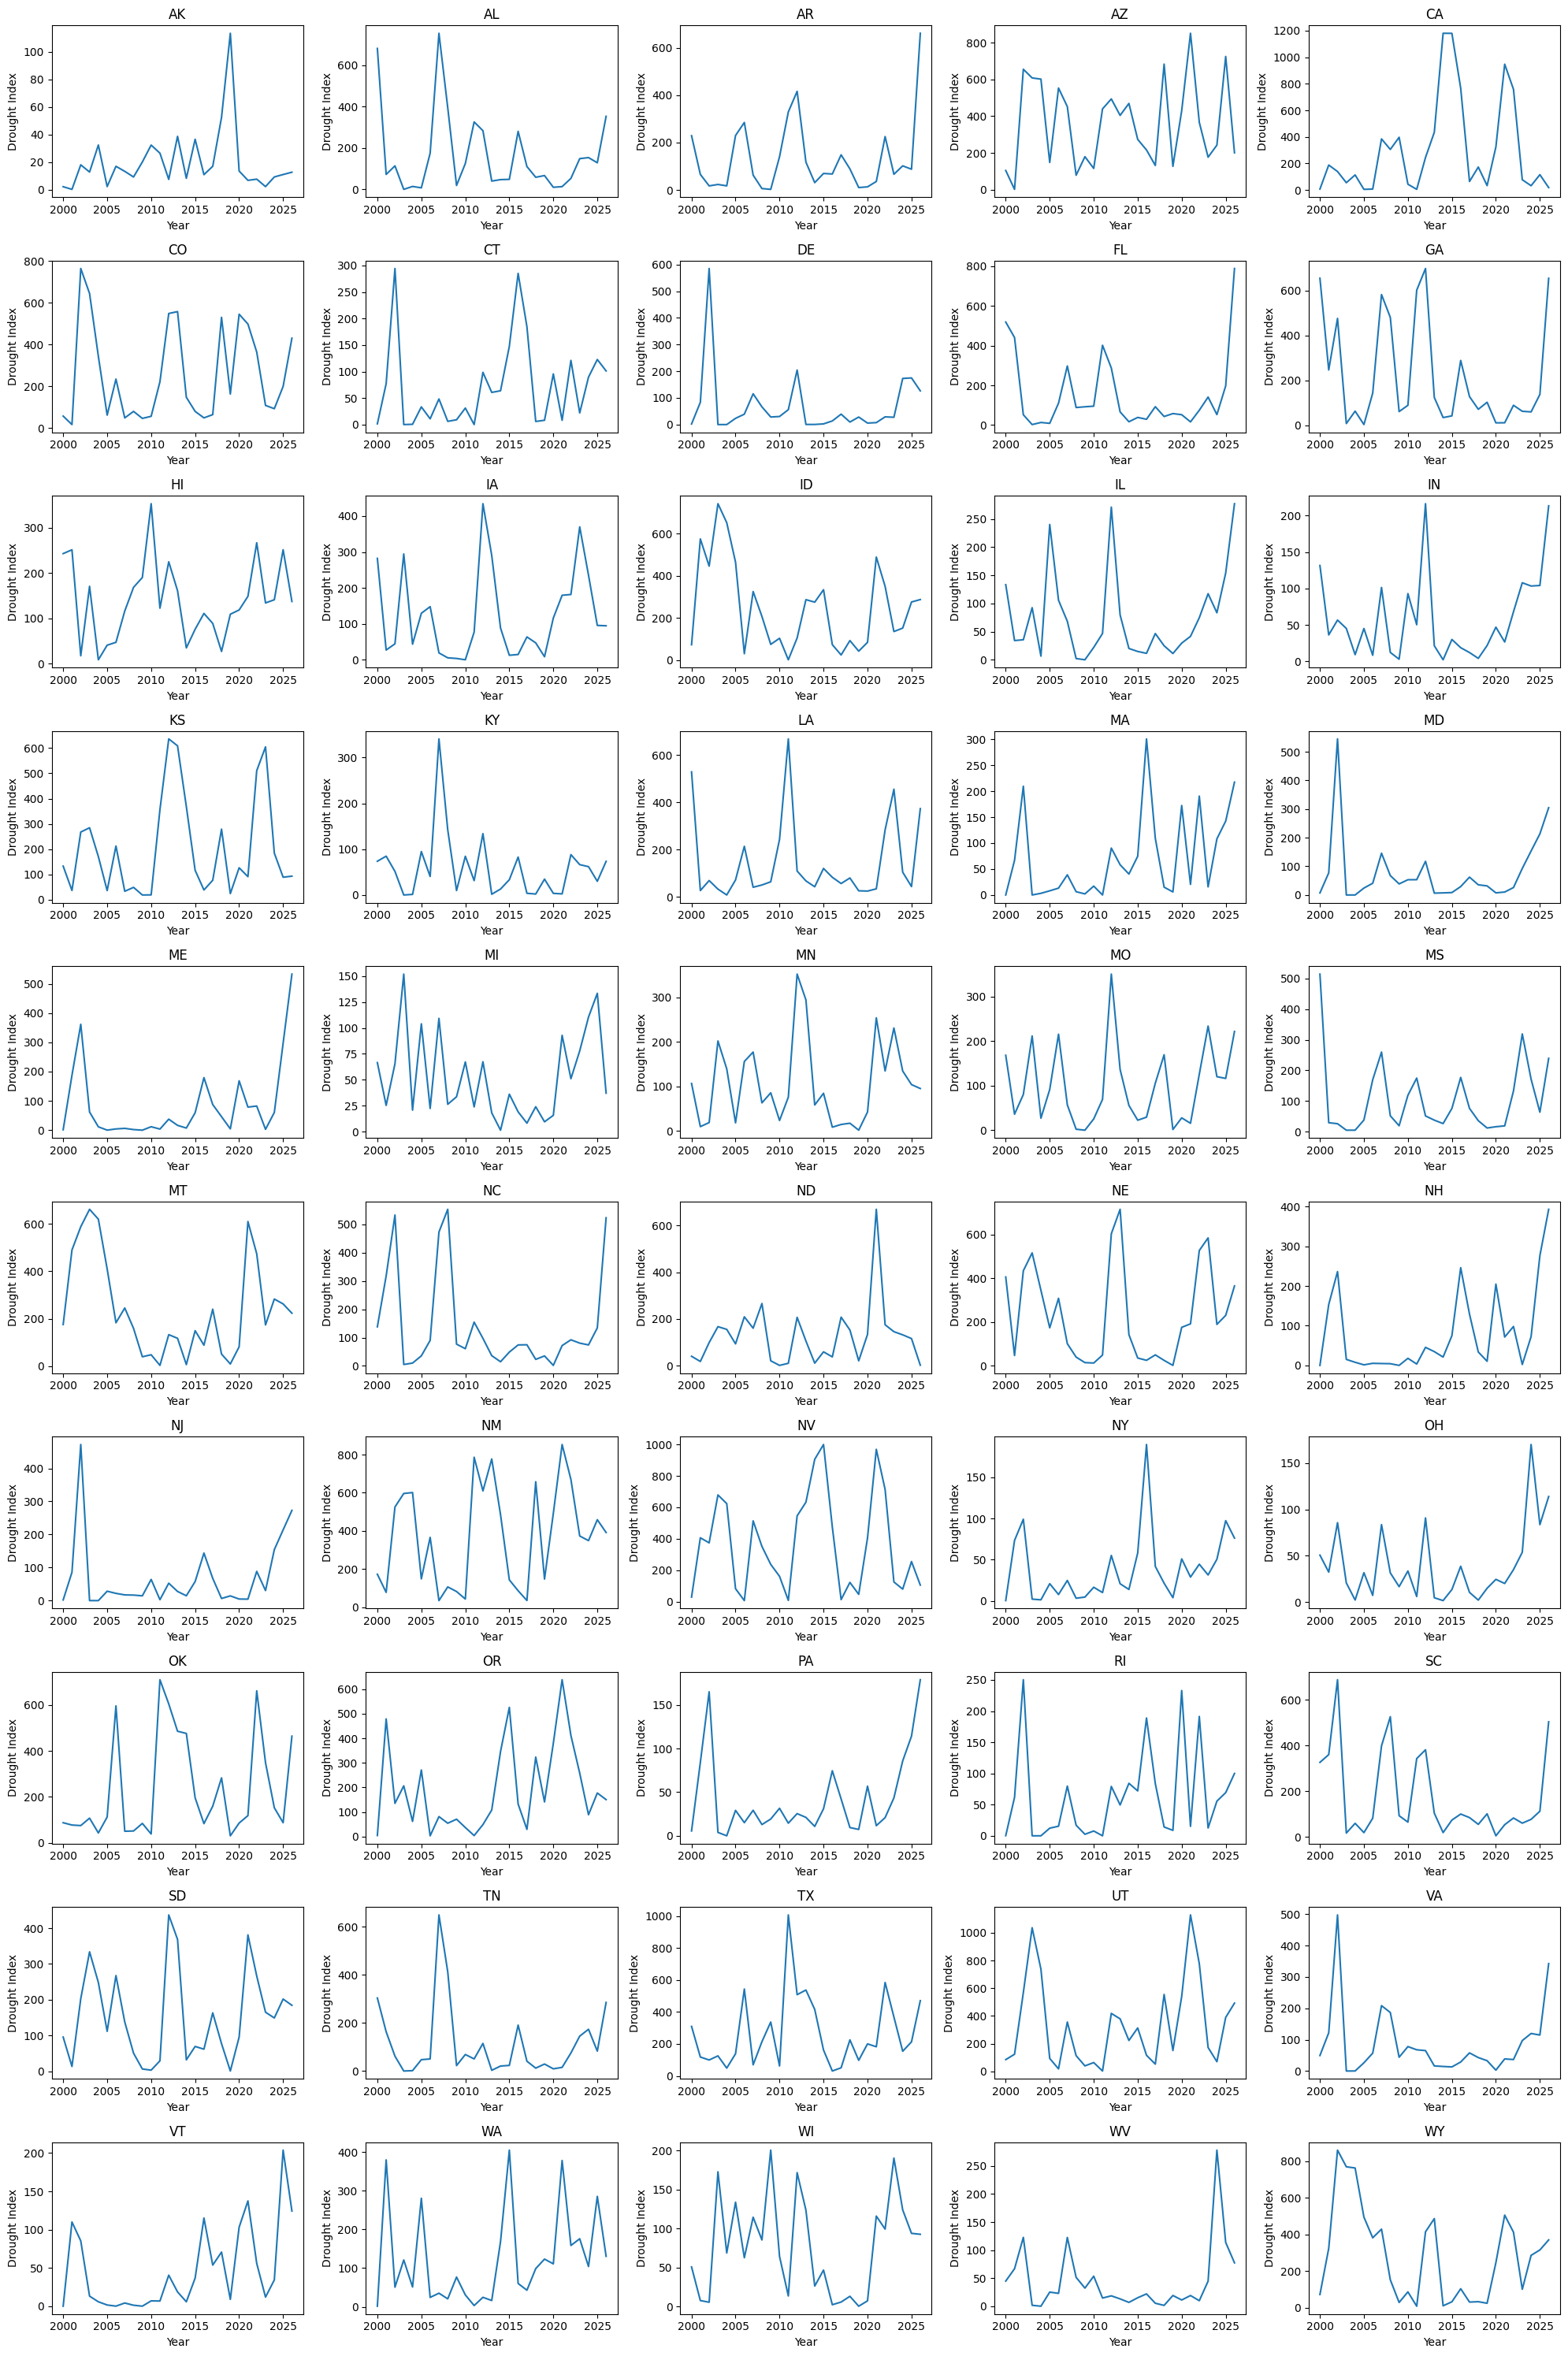

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(10, 5, figsize=(20, 30))
axes = axes.flatten()

states = df_modifiedDrought['State'].unique()

for i, state in enumerate(states):
    df_state = df_modifiedDrought[df_modifiedDrought['State'] == state]
    axes[i].plot(df_state['Year'], df_state['Drought Index'])
    axes[i].set_title(state)
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Drought Index')

plt.tight_layout()
plt.show()

   Year State  Corn_Irrigated  Corn_NonIrrigated  Soy_Irrigated  \
0  2000    WY             NaN          60.000000            NaN   
1  2007    AR             NaN                NaN      39.214286   
2  2007    CO      147.238095          56.794118            NaN   
3  2007    KS      167.000000         102.458333      50.384615   
4  2008    AR             NaN                NaN      40.166667   

   Soy_NonIrrigated  Drought Index  
0               NaN      72.962918  
1         22.678571      62.681026  
2               NaN      49.388062  
3         32.960000      32.961172  
4         27.727273       5.945922  


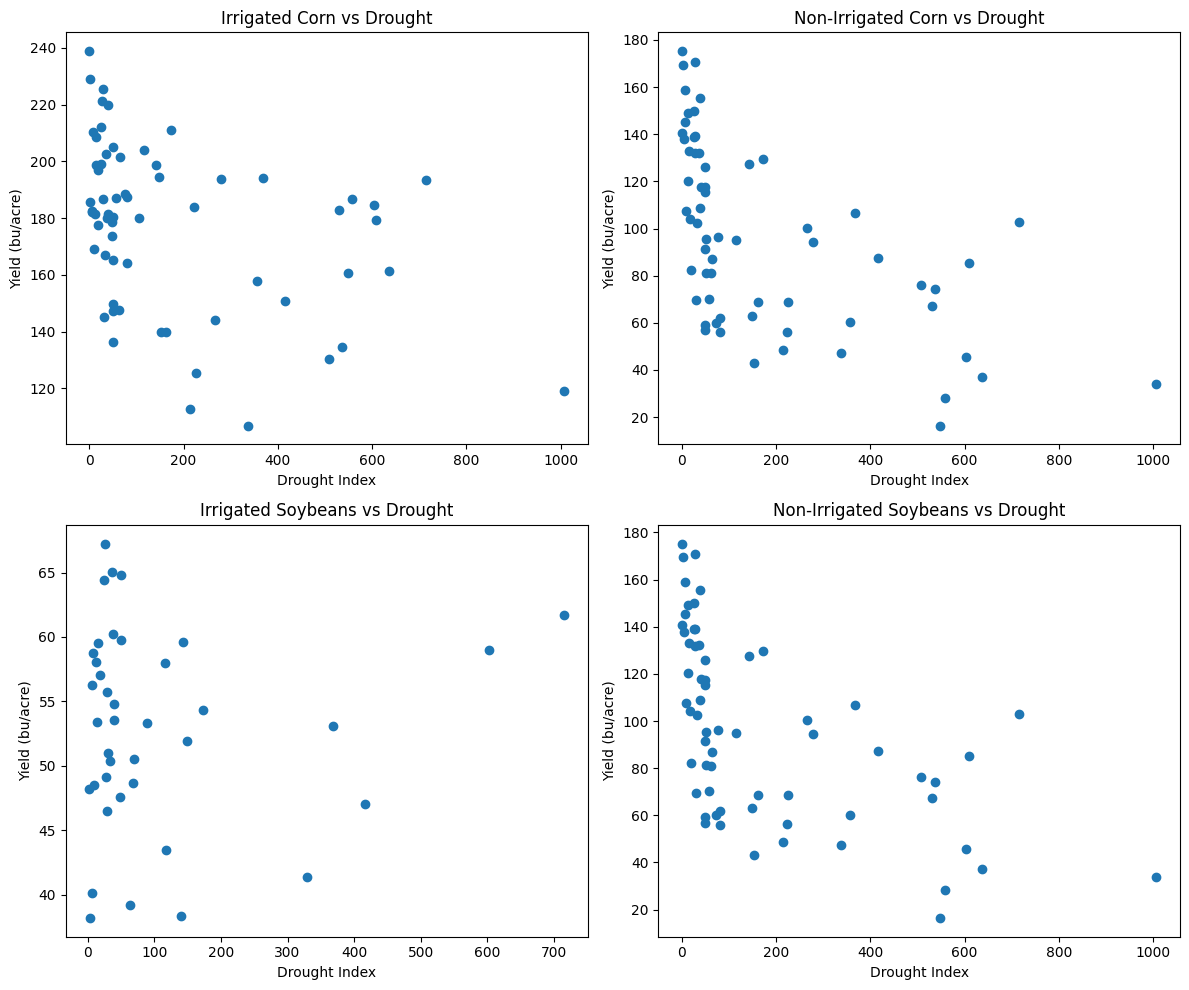

In [ ]:
df_merged = df_modifiedCrops.merge(df_modifiedDrought, on=['Year', 'State'])
#print(df_merged.head())

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0,0].scatter(df_merged['Drought Index'], df_merged['Corn_Irrigated'])
axes[0,0].set_title('Irrigated Corn vs Drought')
axes[0,0].set_xlabel('Drought Index')
axes[0,0].set_ylabel('Yield (bu/acre)')

axes[0,1].scatter(df_merged['Drought Index'], df_merged['Corn_NonIrrigated'])
axes[0,1].set_title('Non-Irrigated Corn vs Drought')
axes[0,1].set_xlabel('Drought Index')
axes[0,1].set_ylabel('Yield (bu/acre)')

axes[1,0].scatter(df_merged['Drought Index'], df_merged['Soy_Irrigated'])
axes[1,0].set_title('Irrigated Soybeans vs Drought')
axes[1,0].set_xlabel('Drought Index')
axes[1,0].set_ylabel('Yield (bu/acre)')

axes[1,1].scatter(df_merged['Drought Index'], df_merged['Corn_NonIrrigated'])
axes[1,1].set_title('Non-Irrigated Soybeans vs Drought')
axes[1,1].set_xlabel('Drought Index')
axes[1,1].set_ylabel('Yield (bu/acre)')

plt.tight_layout()
plt.show()

      Corn_Irrigated  Corn_NonIrrigated  Soy_Irrigated  Soy_NonIrrigated
Year                                                                    
2000             NaN          60.000000            NaN               NaN
2007      157.119048          79.626225      44.799451         27.819286
2008      155.310328          81.715323      47.097222         34.645532
2009      171.193045         107.441490      51.593208         38.636486
2010      173.438298          88.462842      48.214397         32.970131


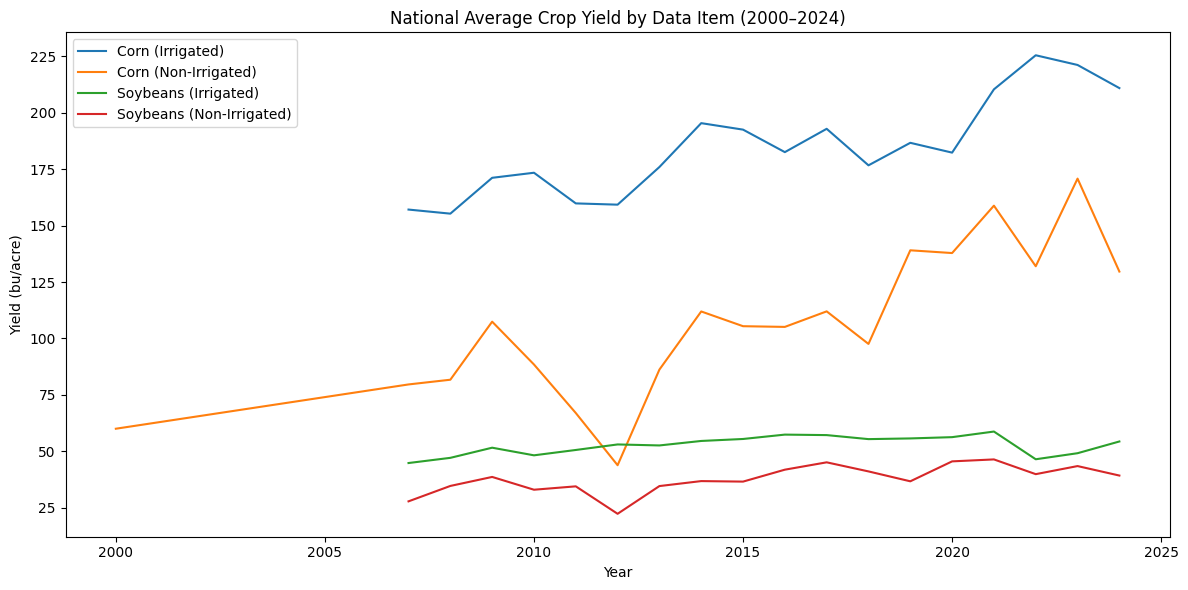

In [12]:
import matplotlib.pyplot as plt

# Average across all states per year
df_national = df_modifiedCrops.groupby('Year')[['Corn_Irrigated', 'Corn_NonIrrigated', 'Soy_Irrigated', 'Soy_NonIrrigated']].mean()
print(df_national.head())
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df_national.index, df_national['Corn_Irrigated'], label='Corn (Irrigated)')
ax.plot(df_national.index, df_national['Corn_NonIrrigated'], label='Corn (Non-Irrigated)')
ax.plot(df_national.index, df_national['Soy_Irrigated'], label='Soybeans (Irrigated)')
ax.plot(df_national.index, df_national['Soy_NonIrrigated'], label='Soybeans (Non-Irrigated)')

ax.set_title('National Average Crop Yield by Data Item (2000–2024)')
ax.set_xlabel('Year')
ax.set_ylabel('Yield (bu/acre)')
ax.legend()
plt.tight_layout()
plt.show()
